# Feedforward Neural Network

---
## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PROCESSED_DIR = './processed'
OUT_DIR       = '../project/outputs/ffnn'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Using device: cpu
Config OK. Output directory: ../project/outputs/ffnn


---
## Load Pre-Processed Artefacts

In [ ]:
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv', index_col=0)
X_test = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv', index_col=0)

X_train = X_train.apply(pd.to_numeric, errors='coerce').astype(np.float32)
X_val = X_val.apply(pd.to_numeric, errors='coerce').astype(np.float32)
X_test = X_test.apply(pd.to_numeric, errors='coerce').astype(np.float32)

# Handle any NaNs introduced during coercion
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Regression targets
y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv', index_col=0).squeeze()
y_reg_test = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv', index_col=0).squeeze()

feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')

# Sanity checks
print('\nDtype check:', X_train.values.dtype)
print('NaNs in train:', np.isnan(X_train.values).sum())

print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')

Loaded splits:
  Train   64000 rows  49 features
  Val      8000 rows  49 features
  Test     8000 rows  49 features

Dtype check: float32
NaNs in train: 0

Regression target  — mean=89.15, std=11.57


---
## Helper: Convert to PyTorch Tensors & DataLoaders

In [3]:
def make_loader(X, y, batch_size=512, shuffle=True, task='regression'):
    """Convert pandas DataFrames/Series to a PyTorch DataLoader."""
    X_t = torch.tensor(X.values, dtype=torch.float32)
    if task == 'regression':
        y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    else:
        y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 512
INPUT_DIM  = X_train.shape[1]
print(f'Input dimension: {INPUT_DIM}')

Input dimension: 49


---
## FFNN Architecture

In [ ]:
class FFNN(nn.Module):
 
    def __init__(self, input_dim, hidden_dims=(256, 128, 64, 32),
                 dropout_rates=(0.3, 0.3, 0.2, 0.0), output_dim=1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim, drop in zip(hidden_dims, dropout_rates):
            layers += [
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
            ]
            if drop > 0:
                layers.append(nn.Dropout(drop))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

dummy = torch.randn(4, INPUT_DIM)
model_check = FFNN(INPUT_DIM)
print('Output shape:', model_check(dummy).shape)   # expect (4, 1)
total_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Output shape: torch.Size([4, 1])
Trainable parameters: 57,025


---
## Training Utility

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=100, patience=10, task='regression'):
    """
    Generic training loop with early stopping.

    Returns
    -------
    history : dict with 'train_loss' and 'val_loss' lists.
    """
    model.to(DEVICE)
    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stop at epoch {epoch}  (best val loss={best_val_loss:.5f})')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:4d} | train={train_loss:.5f} | val={val_loss:.5f}')

    model.load_state_dict(best_state)
    return history


def plot_loss_curve(history, title, save_path):
    plt.figure(figsize=(9, 4))
    plt.plot(history['train_loss'], label='Train loss')
    plt.plot(history['val_loss'],   label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

---
## Regression Task — Predict `exam_score`

In [6]:
reg_train_loader = make_loader(X_train, y_reg_train, BATCH_SIZE, shuffle=True,  task='regression')
reg_val_loader   = make_loader(X_val,   y_reg_val,   BATCH_SIZE, shuffle=False, task='regression')

configs = [
    {'hidden_dims': (128, 64, 32),       'lr': 1e-3, 'label': 'Shallow (128-64-32)'},
    {'hidden_dims': (256, 128, 64, 32),  'lr': 1e-3, 'label': 'Default (256-128-64-32)'},
    {'hidden_dims': (512, 256, 128, 64), 'lr': 5e-4, 'label': 'Wide (512-256-128-64)'},
]

results_search = []
for cfg in configs:
    print(f"\nTraining: {cfg['label']}")
    m = FFNN(INPUT_DIM, hidden_dims=cfg['hidden_dims'])
    opt = optim.Adam(m.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    h   = train_model(m, reg_train_loader, reg_val_loader,
                      nn.MSELoss(), opt, sch, epochs=150, patience=15)
    # Val RMSE
    m.eval()
    with torch.no_grad():
        preds = m(torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()
    val_rmse = np.sqrt(mean_squared_error(y_reg_val, preds))
    results_search.append({'label': cfg['label'], 'val_rmse': val_rmse, 'model': m, 'history': h})
    print(f'  Val RMSE: {val_rmse:.3f}')

best_reg_result = min(results_search, key=lambda x: x['val_rmse'])
print(f"\nBest config: {best_reg_result['label']}  (Val RMSE={best_reg_result['val_rmse']:.3f})")
ffnn_reg = best_reg_result['model']


Training: Shallow (128-64-32)
  Epoch   10 | train=428.24819 | val=271.33660
  Epoch   20 | train=221.37630 | val=115.87666
  Epoch   30 | train=206.32582 | val=115.33132
  Early stop at epoch 34  (best val loss=114.75660)
  Val RMSE: 10.712

Training: Default (256-128-64-32)
  Epoch   10 | train=360.63047 | val=264.58306
  Epoch   20 | train=119.14857 | val=110.88387
  Epoch   30 | train=116.23810 | val=111.92819
  Early stop at epoch 39  (best val loss=110.04309)
  Val RMSE: 10.490

Training: Wide (512-256-128-64)
  Epoch   10 | train=1797.31767 | val=1565.44108
  Epoch   20 | train=119.84034 | val=112.04499
  Epoch   30 | train=109.88686 | val=110.91826
  Early stop at epoch 38  (best val loss=110.60548)
  Val RMSE: 10.517

Best config: Default (256-128-64-32)  (Val RMSE=10.490)


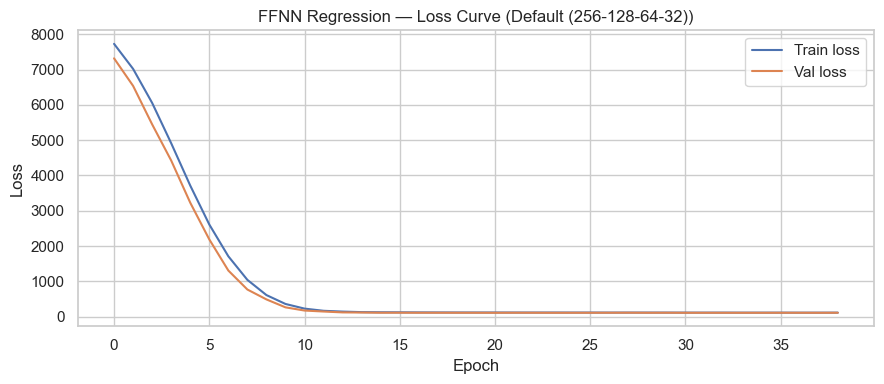

In [7]:
plot_loss_curve(
    best_reg_result['history'],
    f"FFNN Regression — Loss Curve ({best_reg_result['label']})",
    f'{OUT_DIR}/figures/reg_loss_curve.png'
)

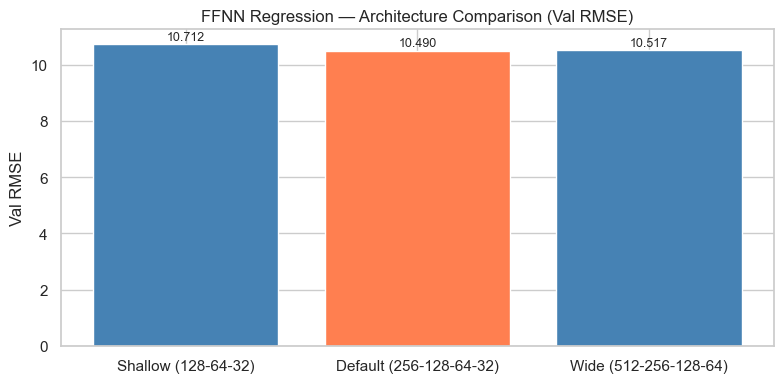

In [8]:
labels    = [r['label']    for r in results_search]
val_rmses = [r['val_rmse'] for r in results_search]

colors = ['steelblue' if l != best_reg_result['label'] else 'coral' for l in labels]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, val_rmses, color=colors)
plt.ylabel('Val RMSE')
plt.title('FFNN Regression — Architecture Comparison (Val RMSE)')
for bar, v in zip(bars, val_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_arch_comparison.png', dpi=150)
plt.show()

In [9]:
ffnn_reg.eval()
with torch.no_grad():
    y_reg_pred = ffnn_reg(
        torch.tensor(X_test.values, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 35)
print(f'  RMSE : {rmse:.3f}')
print(f'  MAE  : {mae:.3f}')
print(f'  R²   : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  RMSE : 10.663
  MAE  : 8.760
  R²   : 0.1787
───────────────────────────────────


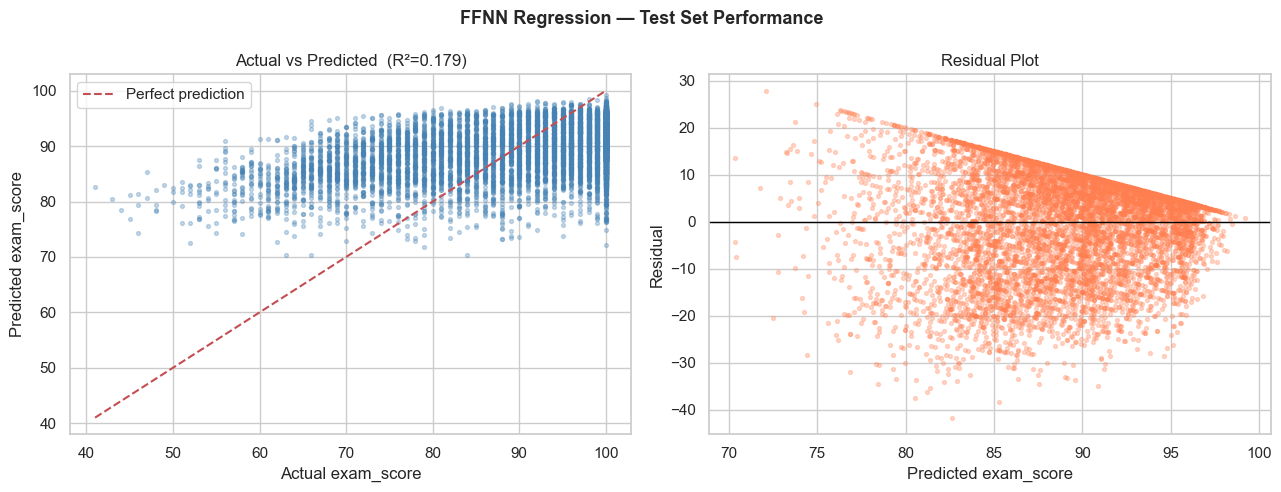

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test.values - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('FFNN Regression — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

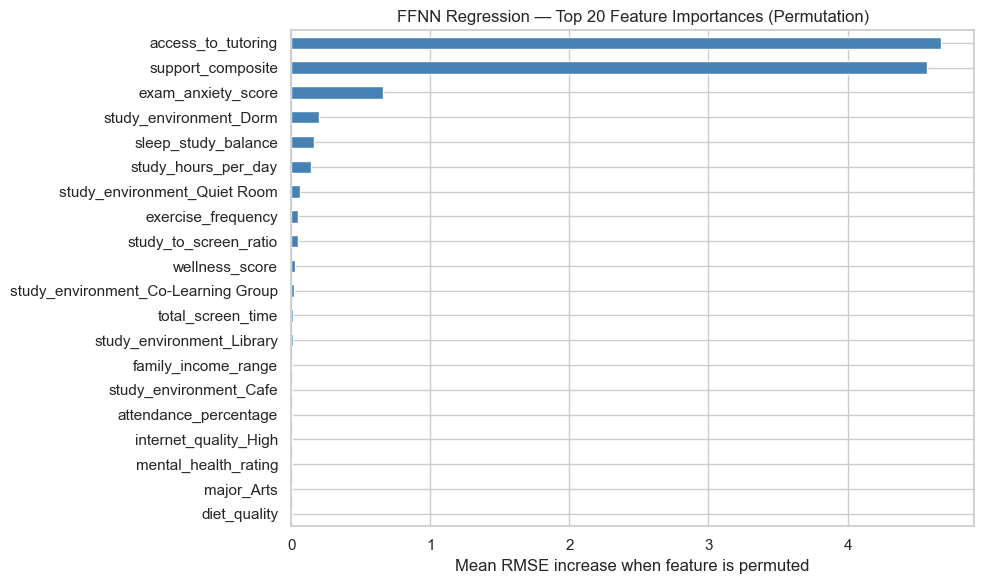

In [11]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

class FFNNSklearnWrapper(BaseEstimator, RegressorMixin):
    """Thin sklearn-compatible wrapper around our PyTorch FFNN."""
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return self.model(t).cpu().numpy().flatten()

wrapped = FFNNSklearnWrapper(ffnn_reg)
perm = permutation_importance(
    wrapped, X_test.values, y_reg_test.values,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)

importances = pd.Series(perm.importances_mean, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean RMSE increase when feature is permuted')
plt.title('FFNN Regression — Top 20 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

In [12]:
torch.save(ffnn_reg.state_dict(), f'{OUT_DIR}/models/ffnn_reg.pt')
print('Regression FFNN saved.')

Regression FFNN saved.


---
## Results Summary

In [13]:
summary = pd.DataFrame([
    {
        'Task':         'Regression (exam_score)',
        'Best Config':  best_reg_result['label'],
        'Test RMSE':    f'{rmse:.3f}',
        'Test MAE':     f'{mae:.3f}',
        'Test R²':      f'{r2:.4f}',
        'Test Acc':     '—',
        'Test F1':      '—',
        'Test AUC':     '—',
    },
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best Config,Test RMSE,Test MAE,Test R²,Test Acc,Test F1,Test AUC
0,Regression (exam_score),Default (256-128-64-32),10.663,8.760,0.1787,—,—,—



All figures saved to: ../project/outputs/ffnn/figures/
All models saved to:  ../project/outputs/ffnn/models/
